# Optimización de Hiperparámetros con Optuna
## LightGBM — Fraude en Hospedaje (MCC 7011) · objetivo: FP ratio a recall ≥ 90%

**Objetivo (Puntos 5–6):** encontrar la configuración de LightGBM que **minimice el FP ratio** en hospedaje cumpliendo **90% de detección (recall ≥ 0.90)**, usando el **último trimestre (meses 4-6)** como test.

**Estrategia:**
1. Búsqueda bayesiana con Optuna (TPE) sobre un espacio regularizado.
2. Validación temporal en el **mes 3** (early stopping + objetivo `1 − FP_ratio | recall ≥ 90%`).
3. Reentreno final con el trimestre de train completo (meses 1-3).
4. Evaluación en el último trimestre y comparación vs baseline y vs la mejor feval del nb04.

## 1. Imports y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
from pathlib import Path
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve)
import warnings, json
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", None)

# ── Configuración global ──────────────────────────────────────────────────
# Coherente con el Punto 5: test = ÚLTIMO TRIMESTRE (meses 4-6) y la métrica
# comparativa es FP ratio buscando 90% de DETECCIÓN (recall ≥ 0.90).
# La optimización busca el modelo que MINIMIZA el FP ratio a ese 90% de recall.
RANDOM_STATE    = 42
N_TRIALS        = 120
EARLY_STOPPING  = 40
NUM_BOOST_MAX   = 800
ALPHA_M2        = 0.5
MIN_RECALL      = 0.90     # objetivo de detección (90%)
# Rejilla extendida a valores bajos (necesario para alcanzar recall ≥ 90%)
THRESHOLDS      = np.round(np.concatenate([
    np.linspace(0.005, 0.05, 10), np.linspace(0.06, 0.90, 22)]), 4)

PROJECT_ROOT = Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)

print(f"Optuna    : {optuna.__version__}")
print(f"LightGBM  : {lgb.__version__}")
print(f"Objetivo  : minimizar FP ratio con recall ≥ {MIN_RECALL:.0%} | test = meses 4-6")

Optuna    : 4.8.0
LightGBM  : 4.6.0
Objetivo  : minimizar FP ratio con recall ≥ 90% | test = meses 4-6


## 2. Carga de datos y preparación de matrices

In [2]:
# Test = ÚLTIMO TRIMESTRE (meses 4-6). Train = Q1 (meses 1-3), con el mes 3 como
# validación para Optuna / early stopping; el reentreno final usa meses 1-3.
feat_df = pd.read_csv(DATA_PROC / "features_dataset.csv")
for col in ["is_fraud","is_international","is_hotel","hotel_international","hotel_high_distance"]:
    if col in feat_df.columns:
        feat_df[col] = feat_df[col].astype(bool)

TARGET = "is_fraud"
manual_drop = {
    TARGET,
    "transaction_id","pan_masked","pan_hash","DE2_PAN",
    "DE35_track2_data_masked","DE37_retrieval_reference_number",
    "DE38_authorization_code","DE41_terminal_id","DE42_card_acceptor_id",
    "DE43_card_acceptor_name_location","DE102_account_id_1","DE103_account_id_2",
    "client_home_city","bank_code","bank_name","bank_country","bank_tier",
    "approved","DE39_response_code","response_description",
    "DE44_additional_response_data","transaction_date","transaction_datetime",
}

def prep_features(df_ref):
    """One-hot encoding consistente (dummies sobre el dataset completo → mismas columnas para todos los slices)."""
    all_cols  = [c for c in df_ref.columns if c not in manual_drop]
    cat_cols  = df_ref[all_cols].select_dtypes(include=["object","category","string"]).columns.tolist()
    low_card  = [c for c in cat_cols if df_ref[c].nunique() <= 50]
    high_card = [c for c in cat_cols if df_ref[c].nunique() >  50]
    feat_cols = [c for c in all_cols if c not in high_card]
    X = pd.get_dummies(df_ref[feat_cols], columns=low_card, drop_first=True, dtype=float).reset_index(drop=True)
    if high_card:
        print(f"  Descartadas por alta cardinalidad: {high_card}")
    return X

X_all       = prep_features(feat_df)
y_all       = feat_df[TARGET].astype(int).reset_index(drop=True)
month_all   = feat_df["transaction_month"].values
hotel_all   = feat_df["is_hotel"].values.astype(bool)

# Alias retro-compatibles usados por las celdas siguientes
X_train_all, y_train_all = X_all, y_all
month_train, hotel_train = month_all, hotel_all

# Slices por mes
te_mask = np.isin(month_all, [4, 5, 6])     # TEST = último trimestre
va_mask = (month_all == 3)                  # validación (Optuna / threshold)
full_mask = np.isin(month_all, [1, 2, 3])   # reentreno final = Q1 completo

X_test          = X_all[te_mask].reset_index(drop=True)
y_test_np       = y_all[te_mask].values
hotel_mask_test = hotel_all[te_mask]
test_df         = feat_df[te_mask].reset_index(drop=True)   # para ids en el guardado

X_val           = X_all[va_mask].reset_index(drop=True)
y_val           = y_all[va_mask].reset_index(drop=True)
y_val_np        = y_val.values
hotel_mask_val  = hotel_all[va_mask]

X_train_full    = X_all[full_mask].reset_index(drop=True)
y_train_full    = y_all[full_mask].reset_index(drop=True)

print(f"Train Q1 (1-3): {full_mask.sum():,} | Validación (mes 3): {va_mask.sum():,} | Test (4-6): {te_mask.sum():,}")
print(f"Features       : {X_all.shape[1]}")
print(f"Hotel val (m3) : {hotel_mask_val.sum()} txns | fraudes: {y_val_np[hotel_mask_val].sum()}")
print(f"Hotel test(4-6): {hotel_mask_test.sum()} txns | fraudes: {y_test_np[hotel_mask_test].sum()}")

  Descartadas por alta cardinalidad: ['client_id']
Train Q1 (1-3): 50,029 | Validación (mes 3): 17,130 | Test (4-6): 49,974
Features       : 112
Hotel val (m3) : 1521 txns | fraudes: 71
Hotel test(4-6): 4508 txns | fraudes: 201


### 2.1 Por qué NO usamos accuracy — el clasificador trivial

Como advirtieron los asesores: por el fuerte desbalance (~5% de fraude), un modelo que predice **siempre "no-fraude"** alcanza una accuracy altísima sin detectar un solo fraude. Lo verificamos abajo para justificar que la métrica del proyecto es **FP ratio con recall ≥ 90%** (no accuracy): el clasificador trivial **reprueba** esa métrica.

In [3]:
# Clasificador trivial "todo = no-fraude" (predicción constante 0)
print("Clasificador trivial — predice SIEMPRE 'no-fraude' (test = meses 4-6):\n")
for _name, _y in [("Global test", y_test_np),
                  ("Hotel test ", y_test_np[hotel_mask_test])]:
    acc = (1 - _y.mean()) * 100          # accuracy = proporción de negativos
    n_fraude = int(_y.sum())
    print(f"  {_name} | accuracy = {acc:5.2f}%  | fraudes reales no detectados = {n_fraude} "
          f"| recall = 0.0%  | TP=0, FP=0 → FP ratio indefinido")

print("\n→ Accuracy ~95% pero recall = 0%: inútil para fraude.")
print("→ El clasificador trivial NO cumple el objetivo recall ≥ 90%, así que reprueba la")
print("  métrica del proyecto (FP ratio con recall ≥ 90%). Por eso optimizamos esa métrica.")

Clasificador trivial — predice SIEMPRE 'no-fraude' (test = meses 4-6):

  Global test | accuracy = 95.21%  | fraudes reales no detectados = 2393 | recall = 0.0%  | TP=0, FP=0 → FP ratio indefinido
  Hotel test  | accuracy = 95.54%  | fraudes reales no detectados = 201 | recall = 0.0%  | TP=0, FP=0 → FP ratio indefinido

→ Accuracy ~95% pero recall = 0%: inútil para fraude.
→ El clasificador trivial NO cumple el objetivo recall ≥ 90%, así que reprueba la
  métrica del proyecto (FP ratio con recall ≥ 90%). Por eso optimizamos esa métrica.


## 3. feval M2 — `hotel_recall_minus_fpratio`

Métrica de optimización principal: `recall_hotel − α · FP_ratio_hotel`.  
Búsqueda dinámica de umbral en cada evaluación para evitar colapso con el desbalance de clases.

In [4]:
def _cm_hotel(y_h, p_h, t):
    y_pred = (p_h >= t).astype(int)
    tp = int(np.sum((y_h == 1) & (y_pred == 1)))
    fp = int(np.sum((y_h == 0) & (y_pred == 1)))
    fn = int(np.sum((y_h == 1) & (y_pred == 0)))
    return tp, fp, fn


def make_feval_m2(mask, y_true_full, alpha=ALPHA_M2):
    """Closure: feval hotel_recall_minus_fpratio (se usa SOLO para early stopping)."""
    y_h = y_true_full[mask]
    def feval(preds, dataset):
        p   = np.clip(preds, 0, 1)
        p_h = p[mask]
        best = -np.inf
        for t in THRESHOLDS:
            tp, fp, fn = _cm_hotel(y_h, p_h, t)
            rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
            s   = rec - alpha * fpr
            if s > best:
                best = s
        return "hotel_recall_minus_fpratio", best, True
    return feval


def hotel_fpratio_score(p_h, y_h, min_recall=MIN_RECALL):
    """Score alineado a la métrica del proyecto: minimizar FP ratio en hotel
    sujeto a recall ≥ min_recall. Devuelve un valor a MAXIMIZAR:
      - si algún umbral logra recall ≥ min_recall → (1 - FP_ratio) ∈ [0, 1]
      - si ninguno lo logra → (mejor_recall - min_recall) < 0  (guía hacia el SLA)
    Así la optimización persigue exactamente lo que se evalúa, no un proxy."""
    best_ok   = -np.inf      # mejor (1 - fpr) con recall cumplido
    best_rec  = 0.0          # mejor recall alcanzado (por si nadie cumple SLA)
    for t in THRESHOLDS:
        tp, fp, fn = _cm_hotel(y_h, p_h, t)
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
        best_rec = max(best_rec, rec)
        if rec >= min_recall:
            best_ok = max(best_ok, 1.0 - fpr)
    return best_ok if best_ok > -np.inf else (best_rec - min_recall)


feval_m2_val = make_feval_m2(hotel_mask_val, y_val_np)

# Verificación rápida con predicciones aleatorias
_dummy = np.random.rand(len(y_val_np))
_name, _val, _higher = feval_m2_val(_dummy, None)
print(f"feval_m2_val (dummy): {_name} = {_val:.4f}  higher_better={_higher}")
print(f"hotel_fpratio_score (dummy): {hotel_fpratio_score(_dummy[hotel_mask_val], y_val_np[hotel_mask_val]):.4f}")
print("✅ Métricas listas.")

feval_m2_val (dummy): hotel_recall_minus_fpratio = 0.5237  higher_better=True
hotel_fpratio_score (dummy): 0.0474
✅ Métricas listas.


## 4. Función objetivo de Optuna (objetivo alineado + espacio regularizado)

Diagnóstico: el FP ratio en hotel lo gobierna el **ranking** del modelo, no el peso de clase (el barrido de umbral absorbe la calibración); los modelos **complejos** (num_leaves alto) y `scale_pos_weight` extremo **empeoran** el ranking del segmento hotel.

Por eso:

1. **Objetivo alineado a la métrica del proyecto**: se maximiza `1 − FP_ratio_hotel` sujeto a `recall_hotel ≥ 0.90` (con penalización si no se alcanza), es decir, exactamente lo que evalúa el Punto 5.
2. **Espacio de búsqueda regularizado**: `num_leaves ≤ 31`, `scale_pos_weight ≤ 6`, regularización L1/L2 → mejor ranking en hotel.
3. **Validación temporal en el mes 3** (último mes del trimestre de entrenamiento, proxy del trimestre de test 4-6).

In [5]:
# ── Validación = mes 3 (último mes del train Q1, proxy del trimestre de test) ──
# Train interno = meses 1-2. El objetivo = minimizar FP_ratio_hotel cumpliendo
# recall ≥ 90% en validación. Espacio regularizado (modelos simples rankean mejor).
tr_idx = np.where(np.isin(month_train, [1, 2]))[0]
va_idx = np.where(month_train == 3)[0]
h_val  = hotel_train[va_idx]
y_val_obj = y_train_all.values[va_idx]
print(f"Train interno (1-2): {len(tr_idx):,} | Validación (mes 3): {len(va_idx):,} "
      f"| fraudes hotel val: {int(y_val_obj[h_val].sum())}")


def objective(trial: optuna.Trial) -> float:
    params = {
        # arquitectura — DELIBERADAMENTE pequeña (mejor ranking en hotel)
        "num_leaves":        trial.suggest_int("num_leaves", 7, 31),
        "max_depth":         trial.suggest_int("max_depth", 3, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 120),
        "max_bin":           trial.suggest_int("max_bin", 63, 255),
        "learning_rate":     trial.suggest_float("learning_rate", 0.02, 0.08, log=True),
        "subsample":         trial.suggest_float("subsample", 0.7, 1.0),
        "subsample_freq":    1,
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-3, 2.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-3, 2.0, log=True),
        "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 0.3),
        "scale_pos_weight":  trial.suggest_float("scale_pos_weight", 1.0, 6.0),
        "objective":     "binary",
        "force_col_wise": True,
        "verbose":       -1,
        "random_state":  RANDOM_STATE,
        "n_jobs":        4,
    }
    mb = params["max_bin"]

    X_tr, y_tr = X_train_all.iloc[tr_idx], y_train_all.iloc[tr_idx]
    X_va, y_va = X_train_all.iloc[va_idx], y_train_all.iloc[va_idx]

    ds_tr = lgb.Dataset(X_tr, label=y_tr, params={"max_bin": mb}, free_raw_data=False)
    ds_va = lgb.Dataset(X_va, label=y_va, reference=ds_tr,
                        params={"max_bin": mb}, free_raw_data=False)

    booster = lgb.train(
        params, ds_tr,
        num_boost_round = NUM_BOOST_MAX,
        valid_sets      = [ds_va],
        valid_names     = ["val"],
        feval           = make_feval_m2(h_val, y_val_obj),   # solo para early stopping
        callbacks       = [lgb.early_stopping(EARLY_STOPPING, verbose=False),
                           lgb.log_evaluation(period=0)],
    )
    trial.set_user_attr("best_iteration", booster.best_iteration)
    p = np.clip(booster.predict(X_va, num_iteration=booster.best_iteration), 0, 1)
    # Objetivo = 1 - FP_ratio_hotel en validación, sujeto a recall ≥ MIN_RECALL (90%)
    return hotel_fpratio_score(p[h_val], y_val_obj[h_val])


print("\nFunción objetivo definida (validación mes 3, objetivo = 1 − FP_ratio_hotel | recall ≥ %.0f%%)." % (MIN_RECALL*100))
print(f"Espacio REGULARIZADO (num_leaves≤31, scale_pos_weight≤6)  |  {N_TRIALS} trials.")

Train interno (1-2): 32,899 | Validación (mes 3): 17,130 | fraudes hotel val: 71

Función objetivo definida (validación mes 3, objetivo = 1 − FP_ratio_hotel | recall ≥ 90%).
Espacio REGULARIZADO (num_leaves≤31, scale_pos_weight≤6)  |  120 trials.


## 5. Búsqueda bayesiana con Optuna (TPE Sampler)

In [6]:
study = optuna.create_study(
    direction  = "maximize",
    sampler    = optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=20),
    pruner     = optuna.pruners.NopPruner(),
    study_name = "lgb_hotel_fraud_fpratio",
)

# Anclar una configuración simple (modelo pequeño, scale_pos_weight bajo) como
# primer trial → la búsqueda nunca arranca por debajo de ese referente.
study.enqueue_trial({
    "num_leaves": 15, "max_depth": 7, "min_child_samples": 40, "max_bin": 63,
    "learning_rate": 0.06, "subsample": 0.85, "colsample_bytree": 0.85,
    "reg_alpha": 0.05, "reg_lambda": 0.10, "min_split_gain": 0.0,
    "scale_pos_weight": 1.0,
})

print(f"Ejecutando {N_TRIALS} trials…")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best = study.best_trial
_fpr_cv = (1 - best.value) if best.value >= 0 else None
print(f"\n{'='*55}")
print(f"Mejor trial   : #{best.number}")
print(f"Mejor score   : {best.value:.4f}  (= 1 − FP_ratio_hotel con recall ≥ {MIN_RECALL:.0%} en val mes 3)")
print(f"FP ratio val  : {_fpr_cv*100:.1f}%" if _fpr_cv is not None else f"(recall ≥ {MIN_RECALL:.0%} no alcanzado en val: {best.value:.4f})")
print(f"Mejor iter    : {best.user_attrs.get('best_iteration', 'N/A')} árboles")
print(f"\nHiperparámetros óptimos:")
for k, v in best.params.items():
    print(f"  {k:<22}: {v}")

Ejecutando 120 trials…


  0%|          | 0/120 [00:00<?, ?it/s]


Mejor trial   : #71
Mejor score   : 0.0716  (= 1 − FP_ratio_hotel con recall ≥ 90% en val mes 3)
FP ratio val  : 92.8%
Mejor iter    : 90 árboles

Hiperparámetros óptimos:
  num_leaves            : 20
  max_depth             : 5
  min_child_samples     : 51
  max_bin               : 88
  learning_rate         : 0.06656979314063907
  subsample             : 0.9935290035383576
  colsample_bytree      : 0.6734867034313851
  reg_alpha             : 0.01669774316377142
  reg_lambda            : 0.017733083517120808
  min_split_gain        : 0.24966863291537422
  scale_pos_weight      : 2.7000441603980923


## 6. Análisis de la búsqueda

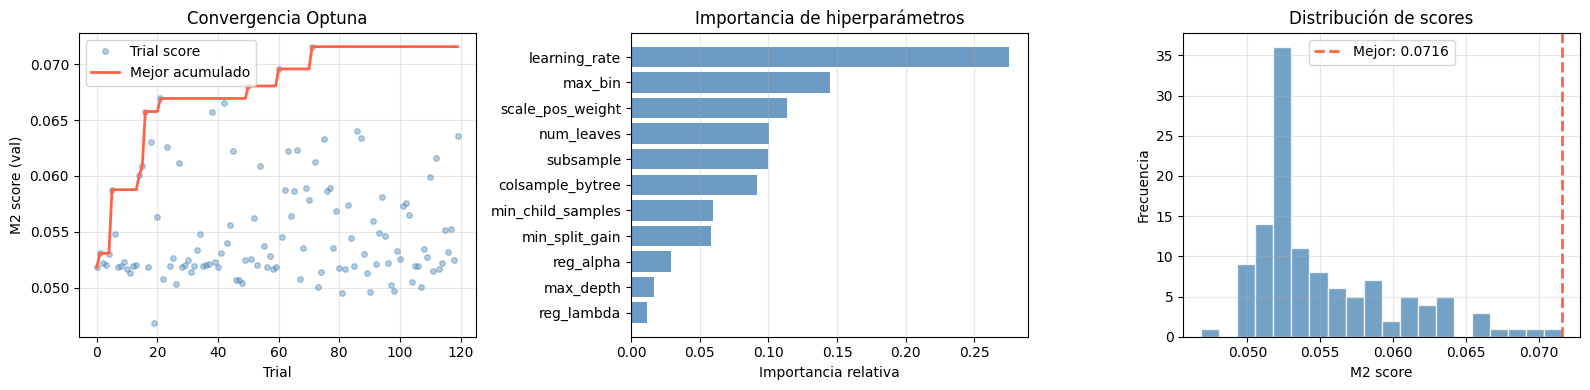

Trials guardados: results/optuna_trials.csv

Top 5 trials:
 number    value
     71 0.071588
     60 0.069593
     50 0.068063
     21 0.066946
     42 0.066534


In [7]:
trials_df = study.trials_dataframe(attrs=("number","value","params","user_attrs"))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Convergencia ──
ax = axes[0]
vals = [t.value for t in study.trials if t.value is not None]
best_so_far = np.maximum.accumulate(vals)
ax.plot(vals, "o", alpha=0.4, markersize=4, color="steelblue", label="Trial score")
ax.plot(best_so_far, "-", color="tomato", linewidth=2, label="Mejor acumulado")
ax.set_xlabel("Trial"); ax.set_ylabel("M2 score (val)")
ax.set_title("Convergencia Optuna"); ax.legend(); ax.grid(alpha=0.3)

# ── Importancia de hiperparámetros ──
ax2 = axes[1]
try:
    importance = optuna.importance.get_param_importances(study)
    keys   = list(importance.keys())
    values = list(importance.values())
    ax2.barh(keys[::-1], values[::-1], color="steelblue", alpha=0.8)
    ax2.set_xlabel("Importancia relativa"); ax2.set_title("Importancia de hiperparámetros")
    ax2.grid(alpha=0.3, axis="x")
except Exception as e:
    ax2.text(0.5, 0.5, str(e), ha="center", va="center", transform=ax2.transAxes)

# ── Distribución de scores ──
ax3 = axes[2]
ax3.hist(vals, bins=20, color="steelblue", alpha=0.75, edgecolor="white")
ax3.axvline(best.value, color="tomato", linewidth=2, linestyle="--",
            label=f"Mejor: {best.value:.4f}")
ax3.set_xlabel("M2 score"); ax3.set_ylabel("Frecuencia")
ax3.set_title("Distribución de scores"); ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "optuna_study_analysis.png", dpi=120, bbox_inches="tight")
plt.show()

# Guardar resultados del estudio
trials_df.to_csv(RESULTS_DIR / "optuna_trials.csv", index=False)
print(f"Trials guardados: results/optuna_trials.csv")
print(f"\nTop 5 trials:")
print(trials_df.sort_values("value", ascending=False).head(5)[
    ["number", "value"]
].to_string(index=False))


## 7. Modelo final — reentreno con mejores hiperparámetros (meses 1–3)

In [8]:
best_params = {**best.params,
               "subsample_freq": 1,
               "objective": "binary", "force_col_wise": True,
               "verbose": -1, "random_state": RANDOM_STATE, "n_jobs": 4}
best_n_iter = max(int(best.user_attrs.get("best_iteration", 200)), 30)

# Reentreno sobre el trimestre de train completo (meses 1-3).
lgb_full_ds = lgb.Dataset(X_train_full, label=y_train_full,
                          params={"max_bin": best_params["max_bin"]},
                          free_raw_data=False)

final_model = lgb.train(
    best_params,
    lgb_full_ds,
    num_boost_round = best_n_iter,
    callbacks       = [lgb.log_evaluation(period=0)],
)

print(f"Modelo final entrenado con {best_n_iter} árboles sobre {len(y_train_full):,} filas (meses 1-3).")
print(f"Parámetros usados:")
for k, v in best_params.items():
    if k not in {"objective","force_col_wise","verbose","random_state","n_jobs"}:
        print(f"  {k:<22}: {v:.4f}" if isinstance(v, float) else f"  {k:<22}: {v}")

Modelo final entrenado con 90 árboles sobre 50,029 filas (meses 1-3).
Parámetros usados:
  num_leaves            : 20
  max_depth             : 5
  min_child_samples     : 51
  max_bin               : 88
  learning_rate         : 0.0666
  subsample             : 0.9935
  colsample_bytree      : 0.6735
  reg_alpha             : 0.0167
  reg_lambda            : 0.0177
  min_split_gain        : 0.2497
  scale_pos_weight      : 2.7000
  subsample_freq        : 1


## 8. Evaluación en Test (último trimestre, meses 4-6)

In [9]:
proba_test  = np.clip(final_model.predict(X_test), 0, 1)
proba_hotel = proba_test[hotel_mask_test]
y_hotel     = y_test_np[hotel_mask_test]

# ── Sweep de umbrales en TEST (hotel, último trimestre) ────────────────────
threshold_rows = []
for t in THRESHOLDS:
    tp, fp, fn = _cm_hotel(y_hotel, proba_hotel, t)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    fpr  = fp / (tp + fp) if (tp + fp) > 0 else 0.0
    threshold_rows.append({"t": round(float(t),4), "tp": tp, "fp": fp, "fn": fn,
                            "recall": rec, "precision": prec, "fp_ratio": fpr})

thr_df = pd.DataFrame(threshold_rows)
valid  = thr_df[thr_df["recall"] >= MIN_RECALL]
best_t = valid.loc[valid["fp_ratio"].idxmin()] if not valid.empty \
         else thr_df.loc[thr_df["recall"].idxmax()]

# ── Umbral elegido en VALIDACIÓN (mes 3) y aplicado al test (honesto) ───────
proba_val   = np.clip(final_model.predict(X_val), 0, 1)
pv_h, yv_h  = proba_val[hotel_mask_val], y_val_np[hotel_mask_val]
_val_rows = []
for t in THRESHOLDS:
    tp, fp, fn = _cm_hotel(yv_h, pv_h, t)
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (tp + fp) if (tp + fp) > 0 else 0.0
    _val_rows.append({"t": float(t), "recall": rec, "fp_ratio": fpr})
_val_df = pd.DataFrame(_val_rows)
_val_ok = _val_df[_val_df["recall"] >= MIN_RECALL]
t_val   = float((_val_ok.loc[_val_ok["fp_ratio"].idxmin()] if not _val_ok.empty
                 else _val_df.loc[_val_df["recall"].idxmax()])["t"])
_tp, _fp, _fn = _cm_hotel(y_hotel, proba_hotel, t_val)
val_thr_test = {
    "t": t_val, "tp": _tp, "fp": _fp, "fn": _fn,
    "recall": _tp/(_tp+_fn) if (_tp+_fn) else 0.0,
    "precision": _tp/(_tp+_fp) if (_tp+_fp) else 0.0,
    "fp_ratio": _fp/(_tp+_fp) if (_tp+_fp) else 0.0,
}

auc_roc = roc_auc_score(y_test_np, proba_test)
pr_auc  = average_precision_score(y_test_np, proba_test)

print("=" * 64)
print("EVALUACIÓN MODELO OPTIMIZADO — Test último trimestre (hotel MCC 7011)")
print("=" * 64)
print(f"\n  [A] Umbral óptimo post-hoc en test (FP ratio mín. con recall ≥ {MIN_RECALL:.0%}):")
print(f"      umbral={best_t['t']}  TP={int(best_t['tp'])}  FP={int(best_t['fp'])}  FN={int(best_t['fn'])}")
print(f"      recall={best_t['recall']*100:.1f}%  precisión={best_t['precision']*100:.1f}%  "
      f"FP ratio={best_t['fp_ratio']*100:.1f}%  ← métrica objetivo")
print(f"\n  [B] Umbral elegido en VALIDACIÓN (mes 3) y aplicado al test (honesto):")
print(f"      umbral={val_thr_test['t']}  TP={val_thr_test['tp']}  FP={val_thr_test['fp']}  FN={val_thr_test['fn']}")
print(f"      recall={val_thr_test['recall']*100:.1f}%  precisión={val_thr_test['precision']*100:.1f}%  "
      f"FP ratio={val_thr_test['fp_ratio']*100:.1f}%")
print(f"\n  AUC-ROC global = {auc_roc:.4f}   |   PR-AUC global = {pr_auc:.4f}")

print(f"\n  Threshold sweep en test (hotel):")
print(thr_df[["t","tp","fp","fn","recall","precision","fp_ratio"]].to_string(index=False))

EVALUACIÓN MODELO OPTIMIZADO — Test último trimestre (hotel MCC 7011)

  [A] Umbral óptimo post-hoc en test (FP ratio mín. con recall ≥ 90%):
      umbral=0.035  TP=184  FP=2553  FN=17
      recall=91.5%  precisión=6.7%  FP ratio=93.3%  ← métrica objetivo

  [B] Umbral elegido en VALIDACIÓN (mes 3) y aplicado al test (honesto):
      umbral=0.06  TP=162  FP=1158  FN=39
      recall=80.6%  precisión=12.3%  FP ratio=87.7%

  AUC-ROC global = 0.8935   |   PR-AUC global = 0.7942

  Threshold sweep en test (hotel):
    t  tp   fp  fn   recall  precision  fp_ratio
0.005 201 4307   0 1.000000   0.044587  0.955413
0.010 201 4306   0 1.000000   0.044597  0.955403
0.015 201 4243   0 1.000000   0.045230  0.954770
0.020 194 3990   7 0.965174   0.046367  0.953633
0.025 192 3530   9 0.955224   0.051585  0.948415
0.030 186 3048  15 0.925373   0.057514  0.942486
0.035 184 2553  17 0.915423   0.067227  0.932773
0.040 180 2125  21 0.895522   0.078091  0.921909
0.045 172 1795  29 0.855721   0.087443  0.9

## 9. Comparación vs Baseline y métricas personalizadas (nb04)

Comparación sobre el **mismo test (último trimestre, meses 4-6)** y la misma regla: **mínimo FP ratio con recall ≥ 90%**. Tres modelos:

1. **Baseline** LightGBM básico (`class_weight=balanced`) entrenado en meses 1-3.
2. **Mejor feval del nb04** (la estrategia con menor FP ratio a 90% recall).
3. **Optimizado nb05** (Optuna sobre espacio regularizado).

A 90% de detección el FP ratio es inherentemente alto (fraude hotel muy raro); el objetivo es ver **qué estrategia lo minimiza**.

In [10]:
import pandas as _pd

def _best_at_recall(p_h, y_h, min_recall=MIN_RECALL):
    """Umbral que minimiza FP ratio cumpliendo recall ≥ min_recall (si nadie, máx recall)."""
    rows = []
    for t in THRESHOLDS:
        tp, fp, fn = _cm_hotel(y_h, p_h, t)
        rec = tp/(tp+fn) if (tp+fn) else 0.0
        fpr = fp/(tp+fp) if (tp+fp) else 0.0
        rows.append({"t": float(t), "tp": tp, "fp": fp, "fn": fn, "recall": rec, "fp_ratio": fpr})
    d = _pd.DataFrame(rows); ok = d[d["recall"] >= min_recall]
    return (ok.loc[ok["fp_ratio"].idxmin()] if not ok.empty else d.loc[d["recall"].idxmax()])

# ── Baseline: LightGBM básico (class_weight balanced) entrenado en meses 1-3 ──
base_model = lgb.LGBMClassifier(objective="binary", n_estimators=200, learning_rate=0.06,
    num_leaves=31, min_child_samples=40, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=4, verbose=-1)
base_model.fit(X_train_full, y_train_full)
p_base = np.clip(base_model.predict_proba(X_test)[:, 1], 0, 1)[hotel_mask_test]
bb = _best_at_recall(p_base, y_hotel)
BASELINE_HOTEL = {"model": "Baseline LightGBM (class_weight=balanced)",
    "tp_hotel": int(bb["tp"]), "fp_hotel": int(bb["fp"]), "fn_hotel": int(bb["fn"]),
    "recall_hotel": float(bb["recall"]), "fp_ratio_hotel": float(bb["fp_ratio"]),
    "auc_roc": roc_auc_score(y_test_np, np.clip(base_model.predict_proba(X_test)[:,1],0,1)),
    "threshold": float(bb["t"])}

# ── Mejor feval del nb04 (a recall ≥ 90%, mismo test) ─────────────────────
CUSTOM_HOTEL = None
_cm_path = RESULTS_DIR / "custom_metrics_results.csv"
if _cm_path.exists():
    _cm = _pd.read_csv(_cm_path)
    _ok = _cm[_cm["recall_hotel"] >= MIN_RECALL]
    _cb = (_ok if not _ok.empty else _cm).nsmallest(1, "fp_ratio_hotel").iloc[0]
    CUSTOM_HOTEL = {"model": f"Custom feval nb04 ({_cb['metric']})",
        "tp_hotel": int(_cb["tp_hotel"]), "fp_hotel": int(_cb["fp_hotel"]), "fn_hotel": int(_cb["fn_hotel"]),
        "recall_hotel": float(_cb["recall_hotel"]), "fp_ratio_hotel": float(_cb["fp_ratio_hotel"]),
        "auc_roc": float(_cb["auc_roc_global"]), "threshold": float(_cb["best_threshold"])}

OPT_HOTEL = {"model": "Optimizado nb05 (Optuna)",
    "tp_hotel": int(best_t["tp"]), "fp_hotel": int(best_t["fp"]), "fn_hotel": int(best_t["fn"]),
    "recall_hotel": best_t["recall"], "fp_ratio_hotel": best_t["fp_ratio"],
    "auc_roc": auc_roc, "threshold": best_t["t"]}

_rows = [BASELINE_HOTEL] + ([CUSTOM_HOTEL] if CUSTOM_HOTEL else []) + [OPT_HOTEL]
comparison = pd.DataFrame(_rows)
comparison["recall_pct"]   = (comparison["recall_hotel"]   * 100).round(1)
comparison["fp_ratio_pct"] = (comparison["fp_ratio_hotel"] * 100).round(1)
cols = ["model","threshold","tp_hotel","fp_hotel","fn_hotel","recall_pct","fp_ratio_pct","auc_roc"]

print("\n" + "=" * 80)
print(f"COMPARACIÓN — Hotel MCC 7011 · test último trimestre · FP ratio a recall ≥ {MIN_RECALL:.0%}")
print("=" * 80)
print(comparison[cols].to_string(index=False))

# Mejor estrategia global (menor FP ratio cumpliendo recall ≥ 90%)
reach = comparison[comparison["recall_hotel"] >= MIN_RECALL]
winner = (reach if not reach.empty else comparison).nsmallest(1, "fp_ratio_hotel").iloc[0]
print(f"\n  🏆 Mejor balance (menor FP ratio con recall ≥ {MIN_RECALL:.0%}): {winner['model']}")
print(f"     FP ratio = {winner['fp_ratio_hotel']*100:.1f}%  |  recall = {winner['recall_hotel']*100:.1f}%")
print(f"\n  Nota: a 90% de detección el FP ratio es alto por definición (fraude hotel muy raro);")
print(f"  el objetivo del Punto 5 es identificar qué estrategia logra el MENOR FP ratio a ese recall.")


COMPARACIÓN — Hotel MCC 7011 · test último trimestre · FP ratio a recall ≥ 90%
                                         model  threshold  tp_hotel  fp_hotel  fn_hotel  recall_pct  fp_ratio_pct  auc_roc
     Baseline LightGBM (class_weight=balanced)      0.045       183      2843        18        91.0          94.0 0.897849
Custom feval nb04 (hotel_recall_minus_fpratio)      0.010       182      2672        19        90.6          93.6 0.900400
                      Optimizado nb05 (Optuna)      0.035       184      2553        17        91.5          93.3 0.893465

  🏆 Mejor balance (menor FP ratio con recall ≥ 90%): Optimizado nb05 (Optuna)
     FP ratio = 93.3%  |  recall = 91.5%

  Nota: a 90% de detección el FP ratio es alto por definición (fraude hotel muy raro);
  el objetivo del Punto 5 es identificar qué estrategia logra el MENOR FP ratio a ese recall.


## 10. Visualizaciones finales

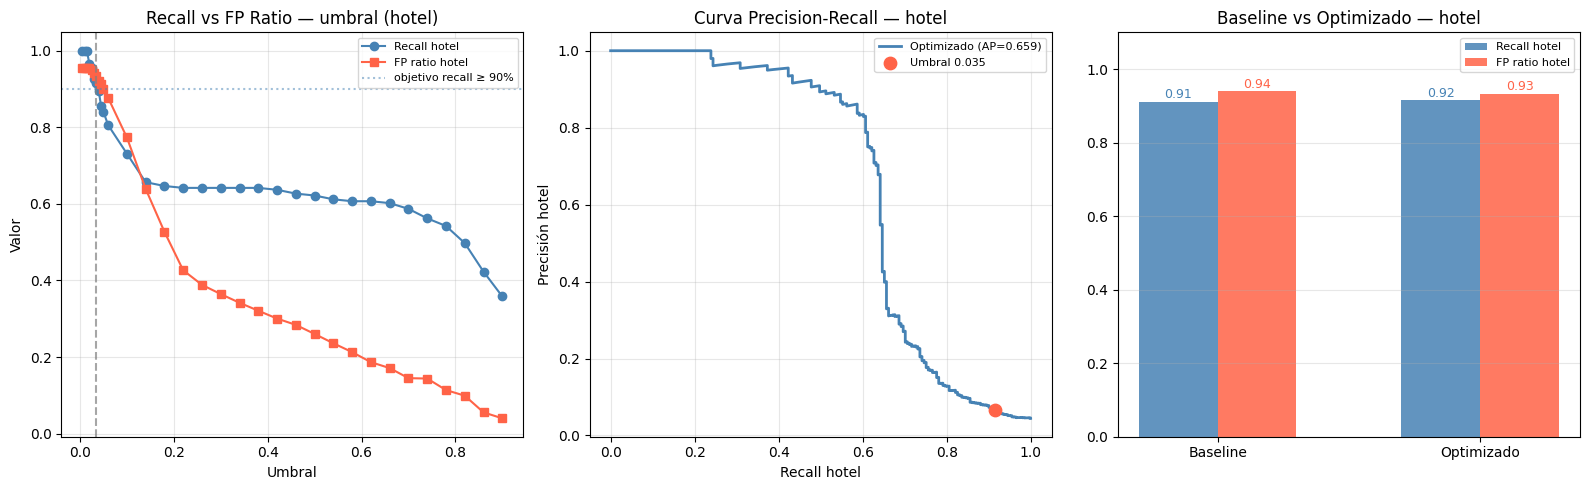

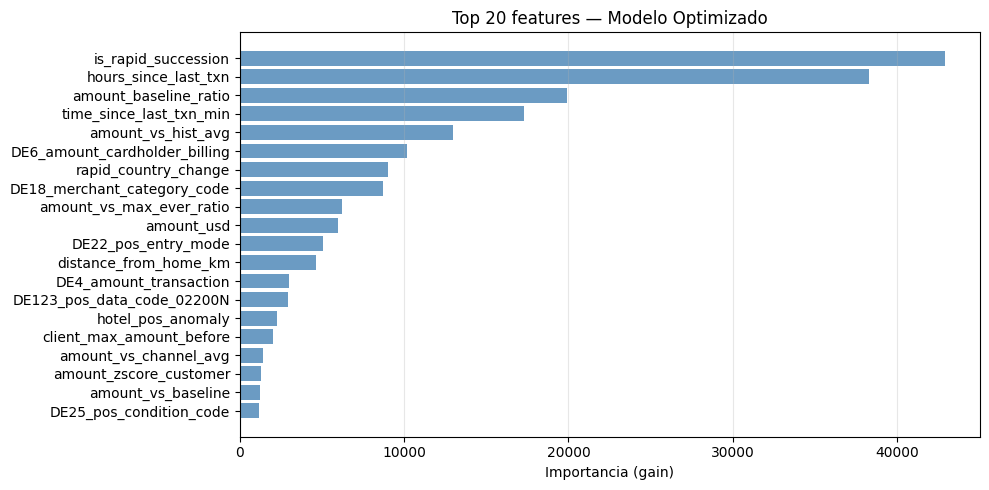

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Threshold sweep: Recall y FP ratio vs umbral ──
ax = axes[0]
ax.plot(thr_df["t"], thr_df["recall"],   "o-", color="steelblue", label="Recall hotel")
ax.plot(thr_df["t"], thr_df["fp_ratio"], "s-", color="tomato",    label="FP ratio hotel")
ax.axvline(best_t["t"], color="gray", linestyle="--", alpha=0.7)
ax.axhline(MIN_RECALL, color="steelblue", linestyle=":", alpha=0.5, label=f"objetivo recall ≥ {MIN_RECALL:.0%}")
ax.set_xlabel("Umbral"); ax.set_ylabel("Valor")
ax.set_title("Recall vs FP Ratio — umbral (hotel)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Curva Precision-Recall (hotel) ──
ax2 = axes[1]
prec_c, rec_c, _ = precision_recall_curve(y_hotel, proba_hotel)
ap_hotel = average_precision_score(y_hotel, proba_hotel)
ax2.plot(rec_c, prec_c, color="steelblue", linewidth=2,
         label=f"Optimizado (AP={ap_hotel:.3f})")
ax2.scatter([best_t["recall"]], [best_t["precision"]],
            color="tomato", zorder=5, s=80, label=f"Umbral {best_t['t']:.3f}")
ax2.set_xlabel("Recall hotel"); ax2.set_ylabel("Precisión hotel")
ax2.set_title("Curva Precision-Recall — hotel"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── Comparación baseline vs optimizado (barras) ──
ax3 = axes[2]
models   = ["Baseline", "Optimizado"]
recalls  = [BASELINE_HOTEL["recall_hotel"],   OPT_HOTEL["recall_hotel"]]
fp_ratios= [BASELINE_HOTEL["fp_ratio_hotel"], OPT_HOTEL["fp_ratio_hotel"]]
x        = np.arange(2); w = 0.3
ax3.bar(x - w/2, recalls,   w, label="Recall hotel",   color="steelblue", alpha=0.85)
ax3.bar(x + w/2, fp_ratios, w, label="FP ratio hotel", color="tomato",    alpha=0.85)
for i, (r, f) in enumerate(zip(recalls, fp_ratios)):
    ax3.text(i-w/2, r+0.01, f"{r:.2f}", ha="center", fontsize=9, color="steelblue")
    ax3.text(i+w/2, f+0.01, f"{f:.2f}", ha="center", fontsize=9, color="tomato")
ax3.set_xticks(x); ax3.set_xticklabels(models)
ax3.set_ylim(0, 1.1); ax3.set_title("Baseline vs Optimizado — hotel")
ax3.legend(fontsize=8); ax3.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "optimized_model_evaluation.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Feature importance del modelo final ──
fi = pd.DataFrame({
    "feature":    final_model.feature_name(),
    "importance": final_model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(10, 5))
plt.barh(fi["feature"][::-1], fi["importance"][::-1], color="steelblue", alpha=0.8)
plt.xlabel("Importancia (gain)"); plt.title("Top 20 features — Modelo Optimizado")
plt.grid(alpha=0.3, axis="x"); plt.tight_layout()
plt.savefig(RESULTS_DIR / "optimized_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## 11. Guardar resultados

In [12]:
with open(RESULTS_DIR / "best_params_optuna.json", "w") as f:
    json.dump({**best_params, "best_iteration": best_n_iter,
               "best_val_score_m2": best.value}, f, indent=2)

preds_out = pd.DataFrame({
    "transaction_id":       test_df["transaction_id"].values
                            if "transaction_id" in test_df.columns
                            else np.arange(len(test_df)),
    "is_hotel":             hotel_mask_test,
    "is_fraud_real":        y_test_np.astype(bool),
    "fraud_prob_optimized": proba_test.round(6),
    "pred_optimized":       (proba_test >= best_t["t"]).astype(bool),
    "threshold_used":       best_t["t"],
})
preds_out.to_csv(RESULTS_DIR / "optimized_predictions_june.csv", index=False)
comparison.to_csv(RESULTS_DIR / "comparison_baseline_vs_optimized.csv", index=False)

print("Archivos guardados en results/")
print()
print(comparison[["model","threshold","tp_hotel","fp_hotel",
                   "recall_pct","fp_ratio_pct","auc_roc"]].to_string(index=False))


Archivos guardados en results/

                                         model  threshold  tp_hotel  fp_hotel  recall_pct  fp_ratio_pct  auc_roc
     Baseline LightGBM (class_weight=balanced)      0.045       183      2843        91.0          94.0 0.897849
Custom feval nb04 (hotel_recall_minus_fpratio)      0.010       182      2672        90.6          93.6 0.900400
                      Optimizado nb05 (Optuna)      0.035       184      2553        91.5          93.3 0.893465
